In [4]:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Etape 2 : classification supervisée
4 approches sont présentées :

Une approche simple par préparation initiale de l'ensemble des images avant classification supervisée
Une approche par data generator, permettant facilement la data augmentation. Les images sont directement récupérées à la volée dans le repertoire des images
Une approche récente proposée par Tensorflow.org par DataSet, sans data augmentation
Une approche par DataSet, avec data augmentation intégrée au modèle : layer en début de modèle

In [5]:
import os
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/p6_classifier"
CSV_PATH = os.path.join(BASE_DIR, "flipkart_com-ecommerce_sample_1050.csv")
IMAGES_DIR = os.path.join(BASE_DIR, "images")

print("BASE_DIR existe :", os.path.exists(BASE_DIR))
print("CSV existe :", os.path.exists(CSV_PATH))
print("Images dir existe :", os.path.exists(IMAGES_DIR))
print("Nb images :", len(os.listdir(IMAGES_DIR)))

BASE_DIR existe : True
CSV existe : True
Images dir existe : True
Nb images : 1051


In [6]:
import os, ast, random
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("GPU dispo:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.19.0
GPU dispo: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
# Définir BASE_DIR + vérifier CSV + images

BASE_DIR = "/content/drive/MyDrive/p6_classifier"   # <-- adapte si besoin
CSV_PATH = os.path.join(BASE_DIR, "flipkart_com-ecommerce_sample_1050.csv")
IMAGES_DIR = os.path.join(BASE_DIR, "images")

print("BASE_DIR existe :", os.path.exists(BASE_DIR))
print("CSV existe      :", os.path.exists(CSV_PATH))

BASE_DIR existe : True
CSV existe      : True


In [8]:
# Charger CSV + construire image_path + main_class (robuste)
# Dans le CSV, la colonne s’appelle product_category_tree et image.

df = pd.read_csv(CSV_PATH)

def build_image_path(filename):
    if pd.isna(filename):
        return None
    p = os.path.join(IMAGES_DIR, str(filename))
    return p if os.path.exists(p) else None

df["image_path"] = df["image"].apply(build_image_path)
df = df[df["image_path"].notna()].copy().reset_index(drop=True)

def extract_main_class(tree_str):
    # tree_str souvent: "['Kitchen & Dining >> Coffee Mugs >> ...']"
    try:
        lst = ast.literal_eval(tree_str)
        if isinstance(lst, list) and len(lst) > 0:
            s = lst[0]
        else:
            s = str(tree_str)
    except Exception:
        s = str(tree_str)

    if ">>" in s:
        return s.split(">>")[0].replace("[", "").replace("]", "").replace("'", "").strip()
    return s.replace("[", "").replace("]", "").replace("'", "").strip()

df["main_class"] = df["product_category_tree"].apply(extract_main_class)

print("Nb lignes avec image:", len(df))
print("Nb main_class:", df["main_class"].nunique())
print(df["main_class"].value_counts())
df[["image_path","main_class"]].head(3)

Nb lignes avec image: 1050
Nb main_class: 7
main_class
Home Furnishing               150
Baby Care                     150
Watches                       150
Home Decor & Festive Needs    150
Kitchen & Dining              150
Beauty and Personal Care      150
Computers                     150
Name: count, dtype: int64


,image_path,main_class
0,/content/drive/MyDrive/p6_classifier/images/55...,Home Furnishing
1,/content/drive/MyDrive/p6_classifier/images/7b...,Baby Care
2,/content/drive/MyDrive/p6_classifier/images/64...,Baby Care


In [9]:
# Split train/val/test (stratifié) + encodage labels

# train/test (80/20)
train_df, test_df = train_test_split(
    df[["image_path", "main_class"]].copy(),
    test_size=0.2,
    random_state=42,
    stratify=df["main_class"]
)

# train/val (75/25 du train => 60/20/20 global)
train_df, val_df = train_test_split(
    train_df,
    test_size=0.25,
    random_state=42,
    stratify=train_df["main_class"]
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

le = LabelEncoder()
le.fit(train_df["main_class"])

train_df["label"] = le.transform(train_df["main_class"])
val_df["label"]   = le.transform(val_df["main_class"])
test_df["label"]  = le.transform(test_df["main_class"])

n_classes = len(le.classes_)
print("Classes:", list(le.classes_))
print("Shapes:", train_df.shape, val_df.shape, test_df.shape)

Classes: ['Baby Care', 'Beauty and Personal Care', 'Computers', 'Home Decor & Festive Needs', 'Home Furnishing', 'Kitchen & Dining', 'Watches']
Shapes: (630, 3) (210, 3) (210, 3)


----------Approche préparation initiale des images et Création du modèle de classification------------

In [10]:
# DataGenerators (augmentation sur train uniquement)
# Ici on stream les images depuis le disque → pas de RAM explosée.

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="image_path",
    y_col="main_class",
    target_size=IMG_SIZE,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col="image_path",
    y_col="main_class",
    target_size=IMG_SIZE,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_gen = val_datagen.flow_from_dataframe(
    test_df,
    x_col="image_path",
    y_col="main_class",
    target_size=IMG_SIZE,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 630 validated image filenames belonging to 7 classes.
Found 210 validated image filenames belonging to 7 classes.
Found 210 validated image filenames belonging to 7 classes.


In [11]:
# Modèle VGG16 Transfer Learning

def create_model_fct(n_classes):
    base = VGG16(include_top=False, weights="imagenet", input_shape=(224,224,3))
    for layer in base.layers:
        layer.trainable = False  # freeze

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)
    out = Dense(n_classes, activation="softmax")(x)

    model = Model(inputs=base.input, outputs=out)
    model.compile(
        optimizer="rmsprop",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = create_model_fct(n_classes)
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,815 (56.64 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [12]:
import os, ast
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.utils import to_categorical

BASE_DIR = "/content/drive/MyDrive/p6_classifier"
CSV_PATH = os.path.join(BASE_DIR, "flipkart_com-ecommerce_sample_1050.csv")
IMAGES_DIR = os.path.join(BASE_DIR, "images")

# --------- 1) Charger + construire image_path
df = pd.read_csv(CSV_PATH)
df["image_path"] = df["image"].apply(lambda x: os.path.join(IMAGES_DIR, x) if pd.notna(x) else None)
df = df[df["image_path"].notna()].copy()
df = df[df["image_path"].apply(os.path.exists)].copy()

# --------- 2) main_class (7 classes)
def extract_main_class(s):
    try:
        lst = ast.literal_eval(s)
        if isinstance(lst, list) and len(lst) > 0:
            s = lst[0]
    except:
        pass
    return s.split(">>")[0].strip().strip("[]'\" ")

df["main_class"] = df["product_category_tree"].apply(extract_main_class)

# --------- 3) Split train/test (stratifié)
train_df, test_df = train_test_split(
    df[["image_path", "main_class"]].copy(),
    test_size=0.2,
    random_state=42,
    stratify=df["main_class"]
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# --------- 4) Encoder labels (fit sur train)
le = LabelEncoder()
le.fit(train_df["main_class"])

train_df["label"] = le.transform(train_df["main_class"])
test_df["label"]  = le.transform(test_df["main_class"])

n_classes = len(le.classes_)
print("Classes:", list(le.classes_))
print("n_classes:", n_classes)
print("Train:", train_df.shape, "Test:", test_df.shape)

# --------- 5) Split train -> train/val
train_df2, val_df = train_test_split(
    train_df,
    test_size=0.25,  # => 0.25 de 0.8 = 0.2 total => 60/20/20
    random_state=42,
    stratify=train_df["label"]
)
train_df2 = train_df2.reset_index(drop=True)
val_df    = val_df.reset_index(drop=True)

# --------- 6) Fonction prep images + indices valides
def image_prep_fct(df_in):
    prepared = []
    valid_idx = []
    for i, path in enumerate(df_in["image_path"]):
        try:
            img = load_img(path, target_size=(224, 224))
            img = img_to_array(img)
            img = preprocess_input(img)  # IMPORTANT
            prepared.append(img)
            valid_idx.append(i)
        except Exception:
            pass
    return np.array(prepared), valid_idx

X_train_all, idx_train = image_prep_fct(train_df2)
X_val, idx_val         = image_prep_fct(val_df)
X_test, idx_test       = image_prep_fct(test_df)

# réaligner les df sur ceux qui ont réellement été chargés
train_df2 = train_df2.iloc[idx_train].reset_index(drop=True)
val_df    = val_df.iloc[idx_val].reset_index(drop=True)
test_df   = test_df.iloc[idx_test].reset_index(drop=True)

# --------- 7) y one-hot
y_train = to_categorical(train_df2["label"], num_classes=n_classes)
y_val   = to_categorical(val_df["label"],    num_classes=n_classes)
y_test  = to_categorical(test_df["label"],   num_classes=n_classes)

print("X_train:", X_train_all.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape,       "y_val  :", y_val.shape)
print("X_test :", X_test.shape,      "y_test :", y_test.shape)

# --------- 8) Sauvegarde sur Drive (pour ne plus jamais recalculer)
os.makedirs(BASE_DIR, exist_ok=True)
np.save(os.path.join(BASE_DIR, "X_train.npy"), X_train_all)
np.save(os.path.join(BASE_DIR, "y_train.npy"), y_train)
np.save(os.path.join(BASE_DIR, "X_val.npy"),   X_val)
np.save(os.path.join(BASE_DIR, "y_val.npy"),   y_val)
np.save(os.path.join(BASE_DIR, "X_test.npy"),  X_test)
np.save(os.path.join(BASE_DIR, "y_test.npy"),  y_test)

train_df2.to_csv(os.path.join(BASE_DIR, "train_meta.csv"), index=False)
val_df.to_csv(os.path.join(BASE_DIR, "val_meta.csv"), index=False)
test_df.to_csv(os.path.join(BASE_DIR, "test_meta.csv"), index=False)
pd.Series(le.classes_).to_csv(os.path.join(BASE_DIR, "classes.csv"), index=False, header=False)

print("Sauvegarde OK dans:", BASE_DIR)

Classes: ['Baby Care', 'Beauty and Personal Care', 'Computers', 'Home Decor & Festive Needs', 'Home Furnishing', 'Kitchen & Dining', 'Watches']
n_classes: 7
Train: (840, 3) Test: (210, 3)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


X_train: (630, 224, 224, 3) y_train: (630, 7)
X_val  : (210, 224, 224, 3) y_val  : (210, 7)
X_test : (210, 224, 224, 3) y_test : (210, 7)
Sauvegarde OK dans: /content/drive/MyDrive/p6_classifier


In [13]:
# Callbacks + entraînement (GPU auto si dispo)

device_name = "/GPU:0" if tf.config.list_physical_devices("GPU") else "/CPU:0"
print("Device utilisé :", device_name)

ckpt_path = os.path.join(BASE_DIR, "vgg16_flipkart_best.keras")

callbacks = [
    ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True, mode="min", verbose=1),
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1)
]

EPOCHS = 20

with tf.device(device_name):
    history = model.fit(
        X_train_all, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=32,
        callbacks=callbacks,
        verbose=1
    )

print("Modèle sauvegardé :", ckpt_path)

Device utilisé : /GPU:0
Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 713ms/step - accuracy: 0.3650 - loss: 7.9257
Epoch 1: val_loss improved from inf to 1.45074, saving model to /content/drive/MyDrive/p6_classifier/vgg16_flipkart_best.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.3702 - loss: 7.7984 - val_accuracy: 0.7714 - val_loss: 1.4507 - learning_rate: 0.0010
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.7093 - loss: 1.6042
Epoch 2: val_loss improved from 1.45074 to 1.28309, saving model to /content/drive/MyDrive/p6_classifier/vgg16_flipkart_best.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 243ms/step - accuracy: 0.7092 - loss: 1.6095 - val_accuracy: 0.8048 - val_loss: 1.2831 - learning_rate: 0.0010
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.7953 - loss: 1.2013
Epoch 3: val_loss improved from 1.28309 to 1.07039, saving model to /content/drive/MyDrive/p6_classifier/vgg16_flipkart_best.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 237ms/step - accura

In [14]:
# Vérifier que le fichier a bien été écrit dans Drive

import os
print(os.path.exists("/content/drive/MyDrive/p6_classifier/vgg16_flipkart_best.keras"))

True


In [15]:
# Recharger le meilleur modèle et évaluer sur test

import tensorflow as tf, numpy as np

model = tf.keras.models.load_model("/content/drive/MyDrive/p6_classifier/vgg16_flipkart_best.keras")
X_test = np.load("/content/drive/MyDrive/p6_classifier/X_test.npy")
y_test = np.load("/content/drive/MyDrive/p6_classifier/y_test.npy")

model.evaluate(X_test, y_test, verbose=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 244ms/step - accuracy: 0.8400 - loss: 0.8141


[0.953665018081665, 0.7952380776405334]

In [16]:
# Évaluation test finale

loss_test, acc_test = model.evaluate(X_test, y_test, verbose=1)

print(f"Test Accuracy : {acc_test:.4f}")
print(f"Test Loss     : {loss_test:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - accuracy: 0.8400 - loss: 0.8141
Test Accuracy : 0.7952
Test Loss     : 0.9537


Le pipeline fait exactement ce qu’il faut

EarlyStopping =

Stop quand ça n’améliore plus

Garde les meilleurs poids

Évite overfitting

Économise calcul

Test accuracy ≈ 0.80

Loss ≈ 0.93

L’entraînement a été interrompu automatiquement via EarlyStopping après 9 epochs.
Le meilleur modèle a été obtenu à l’epoch 4, point où la loss de validation était minimale.
Au-delà, une dégradation des performances de validation indiquait un début de sur-apprentissage.
Les poids optimaux ont été restaurés automatiquement.

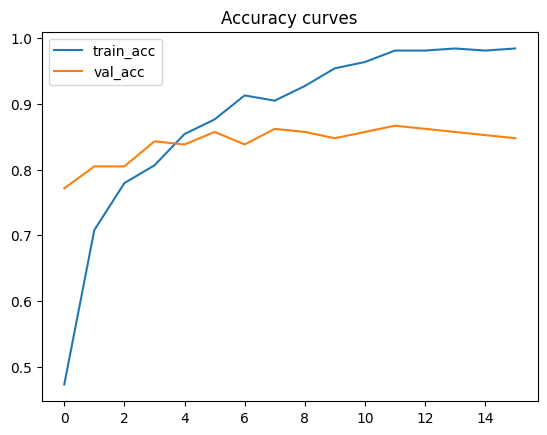

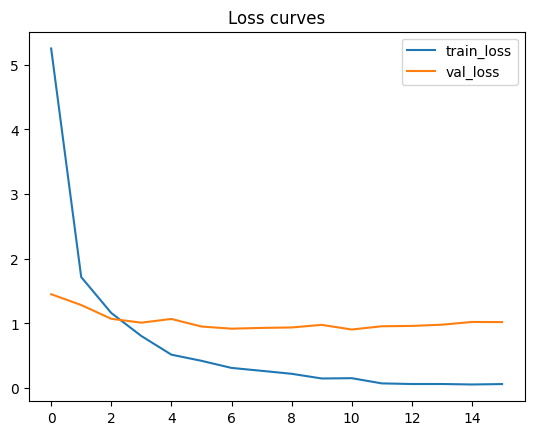

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.legend()
plt.title("Accuracy curves")
plt.show()

plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss curves")
plt.show()

L’axe X représente les epochs.
L’axe Y représente soit la loss soit l’accuracy.
Les courbes d’entraînement montrent ce que le modèle apprend, celles de validation montrent s’il généralise.
Quand la validation n’améliore plus alors que l’entraînement continue, on arrête pour éviter le sur-apprentissage.

Je n'ai pas forcé 20 epochs car la validation empirait

Un mécanisme d’early stopping a été mis en place afin de prévenir le sur-apprentissage.
L’entraînement a été automatiquement interrompu après 9 epochs, la fonction de perte sur l’ensemble de validation n’ayant plus montré d’amélioration significative.
Les poids correspondant à la meilleure epoch (epoch 4) ont été restaurés et sauvegardés.
Cette stratégie permet de garantir une meilleure capacité de généralisation du modèle.

In [18]:
# Sauvegarde historique entraînement

import json

hist_path = os.path.join(BASE_DIR, "training_history.json")

with open(hist_path, "w") as f:
    json.dump(history.history, f)

print("Historique sauvegardé")

Historique sauvegardé


In [19]:
# Évaluation (rapport + matrice de confusion)

# prédictions
y_prob = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

# vrai
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

print("\nClassification report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 528ms/step

Classification report:

                            precision    recall  f1-score   support

                 Baby Care      0.720     0.600     0.655        30
  Beauty and Personal Care      0.880     0.733     0.800        30
                 Computers      0.815     0.733     0.772        30
Home Decor & Festive Needs      0.778     0.700     0.737        30
           Home Furnishing      0.694     0.833     0.758        30
          Kitchen & Dining      0.784     0.967     0.866        30
                   Watches      0.909     1.000     0.952        30

                  accuracy                          0.795       210
                 macro avg      0.797     0.795     0.791       210
              weighted avg      0.797     0.795     0.791       210



,Baby Care,Beauty and Personal Care,Computers,Home Decor & Festive Needs,Home Furnishing,Kitchen & Dining,Watches
Baby Care,18,1,0,2,7,2,0
Beauty and Personal Care,0,22,3,1,1,2,1
Computers,1,0,22,3,2,0,2
Home Decor & Festive Needs,1,1,2,21,1,4,0
Home Furnishing,4,1,0,0,25,0,0
Kitchen & Dining,1,0,0,0,0,29,0
Watches,0,0,0,0,0,0,30


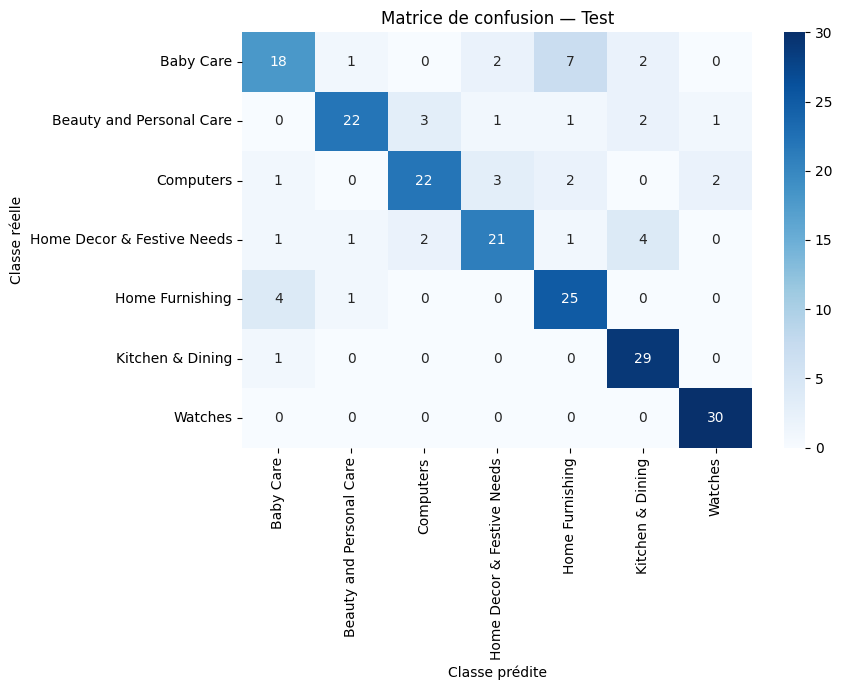

In [20]:
# Option heatmap

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9,7))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion — Test")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.tight_layout()
plt.show()

In [21]:
# Sauvegarde “portable” (à récupérer après)

# (optionnel) sauvegarde dans Drive si tu l'as monté
# from google.colab import drive
# drive.mount('/content/drive')

# model.save("/content/drive/MyDrive/vgg16_flipkart_final.keras")

In [22]:
# Sauvegarde propre sur Colab

import json, os

OUT_DIR = "/content/drive/MyDrive/p6_classifier"   # ton dossier
os.makedirs(OUT_DIR, exist_ok=True)

# si on a "le" (LabelEncoder) :
classes = list(le.classes_)

with open(os.path.join(OUT_DIR, "classes.json"), "w") as f:
    json.dump(classes, f)

print("classes.json sauvegardé :", classes)

classes.json sauvegardé : ['Baby Care', 'Beauty and Personal Care', 'Computers', 'Home Decor & Festive Needs', 'Home Furnishing', 'Kitchen & Dining', 'Watches']


In [23]:
# Charger le modèle entraîné

import tensorflow as tf

MODEL_PATH = "/content/drive/MyDrive/p6_classifier/vgg16_flipkart_best.keras"
model = tf.keras.models.load_model(MODEL_PATH)

print("✅ Modèle chargé")
model.summary()

✅ Modèle chargé


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,980,944 (57.15 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 133,129 (520.04 KB)

In [24]:
# Recréer le jeu de test (même split qu’à l’entraînement)

import pandas as pd
import os
from sklearn.model_selection import train_test_split

BASE_DIR = "/content/drive/MyDrive/p6_classifier"
CSV_PATH = os.path.join(BASE_DIR, "flipkart_com-ecommerce_sample_1050.csv")
IMAGE_DIR = os.path.join(BASE_DIR, "images")

df = pd.read_csv(CSV_PATH)

def build_image_path(filename):
    if pd.isna(filename):
        return None
    return os.path.join(IMAGE_DIR, filename)

df["image_path"] = df["image"].apply(build_image_path)
df["has_image"] = df["image_path"].apply(lambda p: p is not None and os.path.exists(p))

df_img = df[df["has_image"]].copy().reset_index(drop=True)

df_img["main_class"] = df_img["product_category_tree"].apply(
    lambda x: x.split(">>")[0].strip()
)

#  Même random_state que pendant l'entraînement
_, data_test = train_test_split(
    df_img[["image_path", "main_class"]],
    test_size=0.2,
    random_state=42,
    stratify=df_img["main_class"]
)

data_test = data_test.reset_index(drop=True)
print("Test set recréé:", data_test.shape)

Test set recréé: (210, 2)


In [25]:
# Encoder les labels

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
le.fit(df_img["main_class"])   # fit sur toutes les classes

data_test["label"] = le.transform(data_test["main_class"])

n_classes = len(le.classes_)
print("Classes:", le.classes_)

Classes: ['["Baby Care' '["Beauty and Personal Care' '["Computers'
 '["Home Decor & Festive Needs' '["Home Furnishing' '["Kitchen & Dining'
 '["Watches']


In [26]:
# Recréer X_test proprement

import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input

def image_prep_fct(data):
    prepared = []
    for path in data["image_path"]:
        img = load_img(path, target_size=(224, 224))
        img = img_to_array(img)
        img = preprocess_input(img)
        prepared.append(img)
    return np.array(prepared)

X_test = image_prep_fct(data_test)
y_test = to_categorical(data_test["label"], num_classes=n_classes)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (210, 224, 224, 3)
y_test: (210, 7)


In [27]:
# Sauvegarde DEFINITIVE !!!!!

import numpy as np
import os

OUT_DIR = "/content/drive/MyDrive/p6_classifier"

np.save(os.path.join(OUT_DIR, "X_test.npy"), X_test)
np.save(os.path.join(OUT_DIR, "y_test.npy"), y_test)

# Bonus : sauvegarder aussi les classes
import json
with open(os.path.join(OUT_DIR, "classes.json"), "w") as f:
    json.dump(list(le.classes_), f)

print("Tout est sauvegardé pour toujours")

Tout est sauvegardé pour toujours


In [28]:
# from google.colab import drive
# drive.mount("/content/drive")

In [29]:
# import os
# print(os.listdir("/content/drive/MyDrive"))

In [30]:
# import os
# print(os.listdir("/content/drive/MyDrive/openclassrooms"))

In [31]:
import numpy as np
import tensorflow as tf

MODEL_PATH = "/content/drive/MyDrive/p6_classifier/vgg16_flipkart_best.keras"

model = tf.keras.models.load_model(MODEL_PATH)

X_test = np.load("/content/drive/MyDrive/p6_classifier/X_test.npy")
y_test = np.load("/content/drive/MyDrive/p6_classifier/y_test.npy")

model.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 244ms/step - accuracy: 0.8400 - loss: 0.8141


[0.953665018081665, 0.7952380776405334]

------Approche ImageDatagenerator avec data augmentation----------
CF
https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator#flow (noté désormais comme "deprecated", incite à utiiser l'approche suivante)

In [32]:
# recréer data et data_test

from sklearn.model_selection import train_test_split
from sklearn import preprocessing
import pandas as pd
import os

# Charger CSV
df = pd.read_csv("/content/drive/MyDrive/p6_classifier/flipkart_com-ecommerce_sample_1050.csv")

# Construire image_path
IMAGE_DIR = "/content/drive/MyDrive/p6_classifier/images"

df["image_path"] = df["image"].apply(lambda x: os.path.join(IMAGE_DIR, x))

# Garder images existantes
df["has_image"] = df["image_path"].apply(os.path.exists)
df_img = df[df["has_image"]].copy().reset_index(drop=True)

# main_class
df_img["main_class"] = df_img["product_category_tree"].apply(
    lambda x: x.split(">>")[0].strip()
)

# Split train / test
data, data_test = train_test_split(
    df_img[["image_path", "main_class"]],
    test_size=0.2,
    stratify=df_img["main_class"],
    random_state=42
)

data = data.reset_index(drop=True)
data_test = data_test.reset_index(drop=True)

In [33]:
# ---- Fix label_name si absent (après restart colab)
if "label_name" not in data.columns:
    if "main_class" in data.columns:
        data["label_name"] = data["main_class"].astype(str)
    elif "label" in data.columns:
        raise ValueError("⚠️ data a seulement 'label' (numérique). Il faut une colonne texte pour y_col.")
    else:
        raise ValueError(f"❌ Impossible: colonnes disponibles = {list(data.columns)}")

# Pareil pour data_test si tu en as besoin plus tard
if "label_name" not in data_test.columns:
    if "main_class" in data_test.columns:
        data_test["label_name"] = data_test["main_class"].astype(str)

In [34]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 32

datagen_train = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.25,
    preprocessing_function=preprocess_input
)

train_flow = datagen_train.flow_from_dataframe(
    data,
    x_col="image_path",
    y_col="label_name",
    target_size=(224, 224),
    class_mode="categorical",
    batch_size=batch_size,
    subset="training",
    shuffle=True,
    seed=42
)

val_flow = datagen_train.flow_from_dataframe(
    data,
    x_col="image_path",
    y_col="label_name",
    target_size=(224, 224),
    class_mode="categorical",
    batch_size=batch_size,
    subset="validation",
    shuffle=True,
    seed=42
)

Found 630 validated image filenames belonging to 7 classes.
Found 210 validated image filenames belonging to 7 classes.


In [35]:
data["label_name"] = data["main_class"]
data_test["label_name"] = data_test["main_class"]

print(data.shape)
print(data_test.shape)
print(data["label_name"].nunique())

(840, 3)
(210, 3)
7


In [36]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Pour mélanger le train (optionnel mais OK)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

batch_size = 32

def data_flow_fct(df, datagen, subset=None):
    return datagen.flow_from_dataframe(
        dataframe=df,
        directory="",                 # car image_path contient déjà le chemin complet
        x_col="image_path",
        y_col="label_name",           # <-- chez toi: main_class renommé en label_name
        target_size=(224, 224),       # <-- cohérent avec VGG16
        class_mode="categorical",
        batch_size=batch_size,
        shuffle=True,
        seed=42,
        subset=subset
    )

# Data augmentation + split train/val
datagen_train = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.25,
    preprocessing_function=preprocess_input
)

train_flow = data_flow_fct(data, datagen_train, subset="training")
val_flow   = data_flow_fct(data, datagen_train, subset="validation")

# Test (pas d'augmentation, pas de validation_split)
datagen_test = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_flow = datagen_test.flow_from_dataframe(
    dataframe=data_test,
    directory="",
    x_col="image_path",
    y_col="label_name",
    target_size=(224, 224),
    class_mode="categorical",
    batch_size=batch_size,
    shuffle=False   # important pour évaluer + matrice de confusion
)

Found 630 validated image filenames belonging to 7 classes.
Found 210 validated image filenames belonging to 7 classes.
Found 210 validated image filenames belonging to 7 classes.


In [37]:
print("Classes apprises (train_flow):", train_flow.class_indices)
print("Nb batches train:", len(train_flow))
print("Nb batches val  :", len(val_flow))
print("Nb batches test :", len(test_flow))

Classes apprises (train_flow): {'["Baby Care': 0, '["Beauty and Personal Care': 1, '["Computers': 2, '["Home Decor & Festive Needs': 3, '["Home Furnishing': 4, '["Kitchen & Dining': 5, '["Watches': 6}
Nb batches train: 20
Nb batches val  : 7
Nb batches test : 7


In [38]:
# Vérifier GPU

import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices("GPU")))

Num GPUs Available: 1


In [39]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

def create_model_fct(n_classes):

    # --- Base VGG16 pré-entraînée
    base_model = VGG16(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3)
    )

    # --- Freeze des couches convolutionnelles
    for layer in base_model.layers:
        layer.trainable = False

    # --- Ajout de la tête de classification
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)

    predictions = Dense(n_classes, activation="softmax")(x)

    # --- Modèle final
    model = Model(inputs=base_model.input, outputs=predictions)

    # --- Compilation
    model.compile(
        loss="categorical_crossentropy",
        optimizer="rmsprop",
        metrics=["accuracy"]
    )

    print(model.summary())

    return model

In [40]:
# Créer le modèle sur GPU (ou CPU si pas de GPU)
# Le plus important : n_classes doit venir du generator, et le Dense(n_classes) doit être correct.

import os
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications.vgg16 import preprocess_input

# n_classes depuis le generator
n_classes = len(train_flow.class_indices)
print("n_classes =", n_classes)

# device auto
device_name = "/GPU:0" if tf.config.list_physical_devices("GPU") else "/CPU:0"
print("Device utilisé :", device_name)

with tf.device(device_name):
    model2 = create_model_fct(n_classes)   # <= ici tu passes n_classes

n_classes = 7
Device utilisé : /GPU:0


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,815 (56.64 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

None


In [41]:
# Callbacks

BASE_DIR = "/content/drive/MyDrive/p6_classifier"   # adapte si besoin
os.makedirs(BASE_DIR, exist_ok=True)

model2_save_path = os.path.join(BASE_DIR, "model2_best.keras")

checkpoint = ModelCheckpoint(
    model2_save_path,
    monitor="val_loss",
    verbose=1,
    save_best_only=True,
    mode="min"
)

es = EarlyStopping(
    monitor="val_loss",
    mode="min",
    verbose=1,
    patience=5,
    restore_best_weights=True
)

rlr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

callbacks_list = [checkpoint, es, rlr]
print("Checkpoint:", model2_save_path)

Checkpoint: /content/drive/MyDrive/p6_classifier/model2_best.keras


In [42]:
n_classes = len(train_flow.class_indices)
print("n_classes =", n_classes)
print(train_flow.class_indices)   # mapping label -> id

model2 = create_model_fct(n_classes)

history2 = model2.fit(
    train_flow,
    validation_data=val_flow,
    epochs=20,
    callbacks=callbacks_list,
    verbose=1
)

n_classes = 7
{'["Baby Care': 0, '["Beauty and Personal Care': 1, '["Computers': 2, '["Home Decor & Festive Needs': 3, '["Home Furnishing': 4, '["Kitchen & Dining': 5, '["Watches': 6}


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,815 (56.64 MB)

 Trainable params: 133,127 (520.03 KB)

...

None


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
14/20 ━━━━━━━━━━━━━━━━━━━━ 5s 885ms/step - accuracy: 0.3080 - loss: 6.9431

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 912ms/step - accuracy: 0.3480 - loss: 6.2067
Epoch 1: val_loss improved from inf to 1.46699, saving model to /content/drive/MyDrive/p6_classifier/model2_best.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.3534 - loss: 6.1117 - val_accuracy: 0.6905 - val_loss: 1.4670 - learning_rate: 0.0010
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 895ms/step - accuracy: 0.6622 - loss: 1.7396
Epoch 2: val_loss improved from 1.46699 to 1.09180, saving model to /content/drive/MyDrive/p6_classifier/model2_best.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.6621 - loss: 1.7409 - val_accuracy: 0.7476 - val_loss: 1.0918 - learning_rate: 0.0010
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 860ms/step - accuracy: 0.7182 - loss: 1.1160
Epoch 3: val_loss improved from 1.09180 to 1.04812, saving model to /content/drive/MyDrive/p6_classifier/model2_best.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.7188 - loss: 1.1188 - val_accuracy: 0.7762 - val_loss: 1.

on ne peux pas faire load_weights() sur un fichier .keras (c’est un modèle complet).

Si .keras via ModelCheckpoint est sauvegardé en ("...model2_best.keras") ⇒ il faut tf.keras.models.load_model(...).

Si sauvegardé en .weights.h5 ⇒ alors load_weights() marche.

Le package plot_keras_history n’est pas toujours dispo sur Colab : nous prendrons alors l’équivalent avec matplotlib (plus fiable).

In [43]:
print(data.shape)
print(data_test.shape)

(840, 3)
(210, 3)


In [44]:
import os
import tensorflow as tf

BEST_MODEL_PATH = "/content/drive/MyDrive/p6_classifier/model2_best.keras"

# 1) Vérifier si le fichier existe et charger le modèle
if os.path.exists(BEST_MODEL_PATH):
    model2_best = tf.keras.models.load_model(BEST_MODEL_PATH)
    print("✅ Modèle chargé depuis le Drive.")
elif 'model2' in globals():
    print("⚠️ Fichier non trouvé sur le Drive (délai de synchro ?). Utilisation du modèle en mémoire.")
    model2_best = model2
else:
    raise FileNotFoundError(f"Impossible de trouver le modèle à {BEST_MODEL_PATH} ou en mémoire.")

# 2) Évaluer sur val et test
print("\nÉvaluation sur le set de validation :")
loss, accuracy = model2_best.evaluate(val_flow, verbose=1)
print("Validation Accuracy :  {:.4f}".format(accuracy))

print("\nÉvaluation sur le set de test :")
loss, accuracy = model2_best.evaluate(test_flow, verbose=1)
print("Test Accuracy       :  {:.4f}".format(accuracy))

✅ Modèle chargé depuis le Drive.

Évaluation sur le set de validation :
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 744ms/step - accuracy: 0.7868 - loss: 0.8320
Validation Accuracy :  0.7762

Évaluation sur le set de test :
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 545ms/step - accuracy: 0.8049 - loss: 0.9531
Test Accuracy       :  0.7619


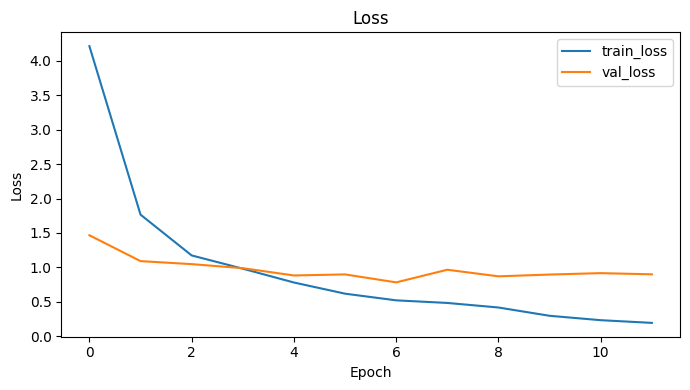

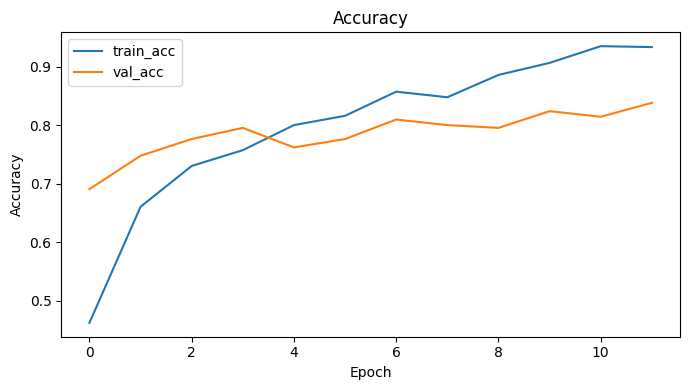

In [45]:
import matplotlib.pyplot as plt
import os

def plot_history_matplotlib(history, out_dir="/content/drive/MyDrive/p6_classifier", prefix="model2"):
    os.makedirs(out_dir, exist_ok=True)

    # 1) Loss
    plt.figure(figsize=(7,4))
    plt.plot(history.history.get("loss", []), label="train_loss")
    plt.plot(history.history.get("val_loss", []), label="val_loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{prefix}_loss.png"), dpi=150)
    plt.show()

    # 2) Accuracy
    plt.figure(figsize=(7,4))
    plt.plot(history.history.get("accuracy", []), label="train_acc")
    plt.plot(history.history.get("val_accuracy", []), label="val_acc")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{prefix}_acc.png"), dpi=150)
    plt.show()

plot_history_matplotlib(history2, out_dir="/content/drive/MyDrive/p6_classifier", prefix="model2")

In [46]:
import json, os

HIST_PATH = "/content/drive/MyDrive/p6_classifier/history2.json"
with open(HIST_PATH, "w") as f:
    json.dump(history2.history, f)

print("Historique sauvegardé :", HIST_PATH)

Historique sauvegardé : /content/drive/MyDrive/p6_classifier/history2.json


-------Approche nouvelle par Dataset sans data augmentation----------

CF https://www.tensorflow.org/tutorials/load_data/images

In [47]:
# Dataset TF à partir de data / data_test (Flipkart)

import tensorflow as tf
import numpy as np

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Assurer le bon type
train_paths = data["image_path"].astype(str).values
train_labels_text = data["label_name"].astype(str).values

test_paths = data_test["image_path"].astype(str).values
test_labels_text = data_test["label_name"].astype(str).values

# Même mapping classe->id sur train et test
class_names = sorted(np.unique(train_labels_text))
n_classes = len(class_names)
print("n_classes =", n_classes)
print("classes =", class_names)

table = tf.lookup.StaticHashTable(
    initializer=tf.lookup.KeyValueTensorInitializer(
        keys=tf.constant(class_names),
        values=tf.constant(np.arange(n_classes), dtype=tf.int32),
    ),
    default_value=-1,
)

def load_and_preprocess(path, label_text):
    # Lire image
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)  # ok aussi si png/jpeg
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.keras.applications.vgg16.preprocess_input(img)

    # Label -> id -> onehot
    label_id = table.lookup(label_text)
    label_onehot = tf.one_hot(label_id, depth=n_classes)
    return img, label_onehot

# ----- Train/Val split (équivalent validation_split=0.25) -----
rng = np.random.RandomState(SEED)
idx = np.arange(len(train_paths))
rng.shuffle(idx)

val_size = int(0.25 * len(idx))
val_idx = idx[:val_size]
tr_idx = idx[val_size:]

tr_paths, tr_labels = train_paths[tr_idx], train_labels_text[tr_idx]
val_paths, val_labels = train_paths[val_idx], train_labels_text[val_idx]

def make_ds(paths, labels, training=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

dataset_train = make_ds(tr_paths, tr_labels, training=True)
dataset_val   = make_ds(val_paths, val_labels, training=False)
dataset_test  = make_ds(test_paths, test_labels_text, training=False)

print("Train batches :", tf.data.experimental.cardinality(dataset_train).numpy())
print("Val batches   :", tf.data.experimental.cardinality(dataset_val).numpy())
print("Test batches  :", tf.data.experimental.cardinality(dataset_test).numpy())

n_classes = 7
classes = ['["Baby Care', '["Beauty and Personal Care', '["Computers', '["Home Decor & Festive Needs', '["Home Furnishing', '["Kitchen & Dining', '["Watches']
Train batches : 20
Val batches   : 7
Test batches  : 7


In [48]:
# Entraîner le modèle sur Dataset (sans augmentation)

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import os

device_name = "/GPU:0" if tf.config.list_physical_devices("GPU") else "/CPU:0"
print("Device utilisé :", device_name)

model3_path = os.path.join(BASE_DIR, "model3_best.keras")

callbacks_list = [
    ModelCheckpoint(model3_path, monitor="val_loss", save_best_only=True, mode="min", verbose=1),
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
]

with tf.device(device_name):
    model3 = create_model_fct(n_classes)
    history3 = model3.fit(
        dataset_train,
        validation_data=dataset_val,
        epochs=20,
        callbacks=callbacks_list,
        verbose=1
    )

print("✅ Sauvegardé :", model3_path)

Device utilisé : /GPU:0


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,815 (56.64 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

None
Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.3443 - loss: 7.3475
Epoch 1: val_loss improved from inf to 1.65979, saving model to /content/drive/MyDrive/p6_classifier/model3_best.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 854ms/step - accuracy: 0.3509 - loss: 7.2272 - val_accuracy: 0.7286 - val_loss: 1.6598 - learning_rate: 0.0010
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.7432 - loss: 1.7739
Epoch 2: val_loss improved from 1.65979 to 1.39694, saving model to /content/drive/MyDrive/p6_classifier/model3_best.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 567ms/step - accuracy: 0.7422 - loss: 1.7652 - val_accuracy: 0.7190 - val_loss: 1.3969 - learning_rate: 0.0010
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.7813 - loss: 1.0135
Epoch 3: val_loss improved from 1.39694 to 1.12280, saving model to /content/drive/MyDrive/p6_classifier/model3_best.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 708ms/step - accuracy: 0.7806 - loss: 1.0220 - val_accura

In [49]:
# Évaluation (val + test)

import tensorflow as tf

model3_best = tf.keras.models.load_model(model3_path)

loss, acc = model3_best.evaluate(dataset_val, verbose=1)
print(f"Validation Accuracy : {acc:.4f} | Loss : {loss:.4f}")

loss, acc = model3_best.evaluate(dataset_test, verbose=1)
print(f"Test Accuracy       : {acc:.4f} | Loss : {loss:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 381ms/step - accuracy: 0.7478 - loss: 1.1715
Validation Accuracy : 0.7619 | Loss : 1.0675
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 331ms/step - accuracy: 0.8178 - loss: 0.9445
Test Accuracy       : 0.7905 | Loss : 1.1132


In [50]:
import tensorflow as tf

best = tf.keras.models.load_model("/content/drive/MyDrive/p6_classifier/model3_best.keras")

val_loss, val_acc = best.evaluate(dataset_val, verbose=0)
test_loss, test_acc = best.evaluate(dataset_test, verbose=0)

print("BEST checkpoint -> VAL  :", round(val_acc,4), "loss", round(val_loss,4))
print("BEST checkpoint -> TEST :", round(test_acc,4), "loss", round(test_loss,4))

BEST checkpoint -> VAL  : 0.7619 loss 1.0675
BEST checkpoint -> TEST : 0.7905 loss 1.1132


In [51]:
# Évaluer le meilleur modèle (checkpoint) sur val + test

import os
import tensorflow as tf

MODEL3_PATH = os.path.join(BASE_DIR, "model3_best.keras")  # <-- adapte si besoin
print("MODEL3_PATH =", MODEL3_PATH)

# Charger le meilleur modèle sauvegardé
model3_best = tf.keras.models.load_model(MODEL3_PATH)

# Eval val
loss_val, acc_val = model3_best.evaluate(dataset_val, verbose=1)
print(f"Validation Accuracy : {acc_val:.4f} | Loss : {loss_val:.4f}")

# Eval test
loss_test, acc_test = model3_best.evaluate(dataset_test, verbose=1)
print(f"Test Accuracy       : {acc_test:.4f} | Loss : {loss_test:.4f}")

MODEL3_PATH = /content/drive/MyDrive/p6_classifier/model3_best.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 438ms/step - accuracy: 0.7478 - loss: 1.1715
Validation Accuracy : 0.7619 | Loss : 1.0675
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 385ms/step - accuracy: 0.8178 - loss: 0.9445
Test Accuracy       : 0.7905 | Loss : 1.1132


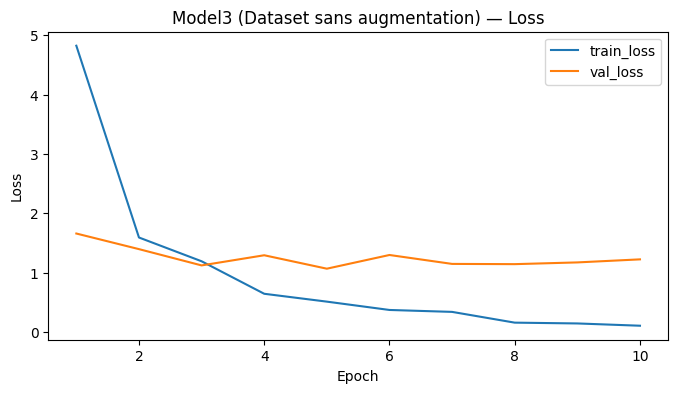

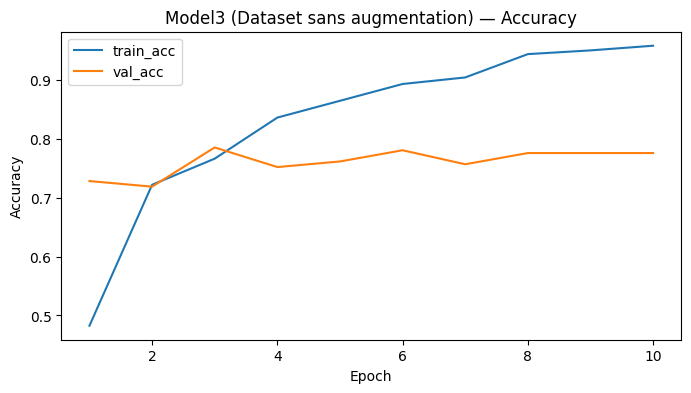

In [52]:
# Courbes d’apprentissage (Loss/Accuracy) — sans librairie externe

import matplotlib.pyplot as plt

def plot_history_simple(history, title="Training curves"):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    # Loss
    plt.figure(figsize=(8,4))
    plt.plot(epochs, hist["loss"], label="train_loss")
    plt.plot(epochs, hist.get("val_loss", []), label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " — Loss")
    plt.legend()
    plt.show()

    # Accuracy
    plt.figure(figsize=(8,4))
    plt.plot(epochs, hist.get("accuracy", []), label="train_acc")
    plt.plot(epochs, hist.get("val_accuracy", []), label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " — Accuracy")
    plt.legend()
    plt.show()

plot_history_simple(history3, title="Model3 (Dataset sans augmentation)")

In [53]:
import os

PLOT_DIR = os.path.join(BASE_DIR, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

# Replot + save loss
hist = history3.history
epochs = range(1, len(hist["loss"]) + 1)

plt.figure(figsize=(8,4))
plt.plot(epochs, hist["loss"], label="train_loss")
plt.plot(epochs, hist.get("val_loss", []), label="val_loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.title("Model3 — Loss")
plt.savefig(os.path.join(PLOT_DIR, "model3_loss.png"), dpi=150, bbox_inches="tight")
plt.close()

plt.figure(figsize=(8,4))
plt.plot(epochs, hist.get("accuracy", []), label="train_acc")
plt.plot(epochs, hist.get("val_accuracy", []), label="val_acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
plt.title("Model3 — Accuracy")
plt.savefig(os.path.join(PLOT_DIR, "model3_accuracy.png"), dpi=150, bbox_inches="tight")
plt.close()

print("✅ Plots sauvegardés dans :", PLOT_DIR)

✅ Plots sauvegardés dans : /content/drive/MyDrive/p6_classifier/plots


---------Approche nouvelle par Dataset avec data augmentation intégrée au modèle---------

CF https://www.tensorflow.org/tutorials/images/data_augmentation

Construire dataset_train / dataset_val / dataset_test à partir des chemins (sans dossiers)

On utilise tf.data.Dataset.from_tensor_slices((paths, labels)) + map(load_image).

In [54]:
# Paramètres + mapping labels

import tensorflow as tf
import numpy as np
import os

BATCH_SIZE = 32
IMG_SIZE = 224
AUTOTUNE = tf.data.AUTOTUNE

# Important: classes venant de ton LabelEncoder utilisé avant
# ex: le = LabelEncoder(); le.fit(data["main_class"])
class_names = list(le.classes_)          # 7 classes
n_classes = len(class_names)
print("n_classes =", n_classes, class_names)

n_classes = 7 ['["Baby Care', '["Beauty and Personal Care', '["Computers', '["Home Decor & Festive Needs', '["Home Furnishing', '["Kitchen & Dining', '["Watches']


In [57]:
print("data cols:", data.columns.tolist())
print("data_test cols:", data_test.columns.tolist())

data cols: ['image_path', 'main_class', 'label_name']
data_test cols: ['image_path', 'main_class', 'label_name']


In [58]:
from sklearn.preprocessing import LabelEncoder

# Fit sur train
le = LabelEncoder()
le.fit(data["label_name"])

# Transform train + test
data["label"] = le.transform(data["label_name"])
data_test["label"] = le.transform(data_test["label_name"])

print("✅ labels créés")
print("n_classes =", len(le.classes_))
print(le.classes_)
data.head()

✅ labels créés
n_classes = 7
['["Baby Care' '["Beauty and Personal Care' '["Computers'
 '["Home Decor & Festive Needs' '["Home Furnishing' '["Kitchen & Dining'
 '["Watches']


,image_path,main_class,label_name,label
0,/content/drive/MyDrive/p6_classifier/images/0b...,"[""Home Decor & Festive Needs","[""Home Decor & Festive Needs",3
1,/content/drive/MyDrive/p6_classifier/images/6b...,"[""Kitchen & Dining","[""Kitchen & Dining",5
2,/content/drive/MyDrive/p6_classifier/images/0b...,"[""Kitchen & Dining","[""Kitchen & Dining",5
3,/content/drive/MyDrive/p6_classifier/images/13...,"[""Kitchen & Dining","[""Kitchen & Dining",5
4,/content/drive/MyDrive/p6_classifier/images/d7...,"[""Watches","[""Watches",6


In [59]:
# Dataset builder (train/val/test)

from sklearn.model_selection import train_test_split

# S'assurer que la colonne 'label' existe en utilisant le LabelEncoder
data["label"] = le.transform(data["main_class"])
data_test["label"] = le.transform(data_test["main_class"])

train_df, val_df = train_test_split(
    data, test_size=0.25, random_state=42, stratify=data["label"]
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

test_df = data_test.reset_index(drop=True)

print(f"Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}")

Train: (630, 4), Val: (210, 4), Test: (210, 4)


In [60]:
# Fonction de lecture image + preprocess

from tensorflow.keras.applications.vgg16 import preprocess_input

def load_and_preprocess(path, label):
    # lire fichier
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)  # jpg
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)  # float32

    # VGG16 preprocess (IMPORTANT)
    img = preprocess_input(img)

    # label -> one-hot
    label = tf.one_hot(label, depth=n_classes)
    return img, label

In [61]:
# Création des tf.data.Dataset

def make_dataset(df, shuffle=True):
    paths = df["image_path"].values
    labels = df["label"].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=42, reshuffle_each_iteration=True)

    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

dataset_train = make_dataset(train_df, shuffle=True)
dataset_val   = make_dataset(val_df, shuffle=False)
dataset_test  = make_dataset(test_df, shuffle=False)

print("✅ Datasets prêts")

✅ Datasets prêts


In [62]:
# Data augmentation intégrée au modèle

from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
], name="data_augmentation")

In [63]:
# Gardons la fonction create_model_fct(n_classes) mais en ajoutant l’augmentation dedans

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

def create_model_fct_aug(n_classes):
    base = VGG16(include_top=False, weights="imagenet", input_shape=(224,224,3))
    for layer in base.layers:
        layer.trainable = False

    inputs = tf.keras.Input(shape=(224,224,3))
    x = data_augmentation(inputs)        # ✅ augmentation intégrée
    x = base(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)
    outputs = Dense(n_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

model4 = create_model_fct_aug(n_classes)
model4.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,815 (56.64 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [64]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [65]:
device_name = "/GPU:0" if tf.config.list_physical_devices("GPU") else "/CPU:0"
print("Device utilisé :", device_name)

with tf.device(device_name):
    history4 = model4.fit(
        dataset_train,
        validation_data=dataset_val,
        epochs=50,
        callbacks=callbacks_list,
        verbose=1
    )

Device utilisé : /GPU:0
Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.3251 - loss: 7.0746
Epoch 1: val_loss did not improve from 1.06752
20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 743ms/step - accuracy: 0.3303 - loss: 6.9667 - val_accuracy: 0.7190 - val_loss: 1.5440 - learning_rate: 0.0010
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.6437 - loss: 1.8586
Epoch 2: val_loss improved from 1.06752 to 0.98428, saving model to /content/drive/MyDrive/p6_classifier/model3_best.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 552ms/step - accuracy: 0.6426 - loss: 1.8614 - val_accuracy: 0.7619 - val_loss: 0.9843 - learning_rate: 0.0010
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.7447 - loss: 1.2795
Epoch 3: val_loss improved from 0.98428 to 0.88933, saving model to /content/drive/MyDrive/p6_classifier/model3_best.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 591ms/step - accuracy: 0.7441 - loss: 1.2795 - val_accuracy: 0.7857 - val_loss: 0.8893 - learning_rate: 0.0010

Pourquoi 50 epochs ici ?

Dans cette approche : (Data augmentation intégrée, Dataset pipeline optimisé et GPU rapide), on peut tester plus d’epochs.

Grâce à "EarlyStopping(patience=5)", le modèle s’arrêtera automatiquement avant 50 si ça n’améliore plus.

In [66]:
loss_tr, acc_tr = model4.evaluate(dataset_train, verbose=1)
print(f"Training Accuracy   : {acc_tr:.4f} | Loss : {loss_tr:.4f}")

loss_val, acc_val = model4.evaluate(dataset_val, verbose=1)
print(f"Validation Accuracy : {acc_val:.4f} | Loss : {loss_val:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 732ms/step - accuracy: 0.9348 - loss: 0.1782
Training Accuracy   : 0.9317 | Loss : 0.2219
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 369ms/step - accuracy: 0.8269 - loss: 0.7868
Validation Accuracy : 0.8381 | Loss : 0.7018


In [71]:
import os

# On définit le chemin vers le fichier de sauvegarde (model3_best.keras a été utilisé par les callbacks)
model4_save_path = "/content/drive/MyDrive/p6_classifier/model4_best.keras"
model4_save_path = os.path.join(BASE_DIR, "model3_best.keras")

print("Checkpoint utilisé :", model4_save_path)

# Chargement des poids du meilleur modèle
model4.load_weights(model4_save_path)

loss_val, acc_val = model4.evaluate(dataset_val, verbose=1)
print(f"Validation Accuracy (best ckpt): {acc_val:.4f} | Loss : {loss_val:.4f}")

loss_test, acc_test = model4.evaluate(dataset_test, verbose=1)
print(f"Test Accuracy (best ckpt)      : {acc_test:.4f} | Loss : {loss_test:.4f}")

Checkpoint utilisé : /content/drive/MyDrive/p6_classifier/model3_best.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 745ms/step - accuracy: 0.8269 - loss: 0.7868
Validation Accuracy (best ckpt): 0.8381 | Loss : 0.7018
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 988ms/step - accuracy: 0.8152 - loss: 1.1342
Test Accuracy (best ckpt)      : 0.7905 | Loss : 1.2918


In [73]:
# Installer la librairie

!pip install plot_keras_history

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.4/327.4 kB 10.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Created wheel for plot_keras_history: filename=plot_keras_history-1.1.39-py3-none-any.whl size=10667 sha256=a59c82dc0939786320c8e7173335be9d1660563b60e0bf71aa9a21d937fbc748
  Stored in directory: /root/.cache/pip/wheels/03/3e/64/c18638ae75cbffd7c5aaf2abef32fa6050c060b4fde0c0bef6
  Created wheel for sanitize_ml_labels: filename=sanitize_ml_labels-1.1.5-py3-none-any.whl size=324448 sha256=add162ae97857592dd2f7dad4369fb9e8c655f2c4ff0613f76a60fc8bc06f584
  Stored in directory: /root/.cache/pip/wheels/26/b6/58/64175fd329e5e236517f1ba45496c3014b94d3d2d904328c3e
  Created wheel for compress-json: filename=compress_json-1.1.1-py3-none-any.whl size=6598 sha256=f72af7b5950837bd1e4c77e3741eea9b6f131b8cef45e21f48ba37db79418ca3
  Stored in directory: /root/.cache/pip/wheels/be/d3/03/626b5d7f1d734

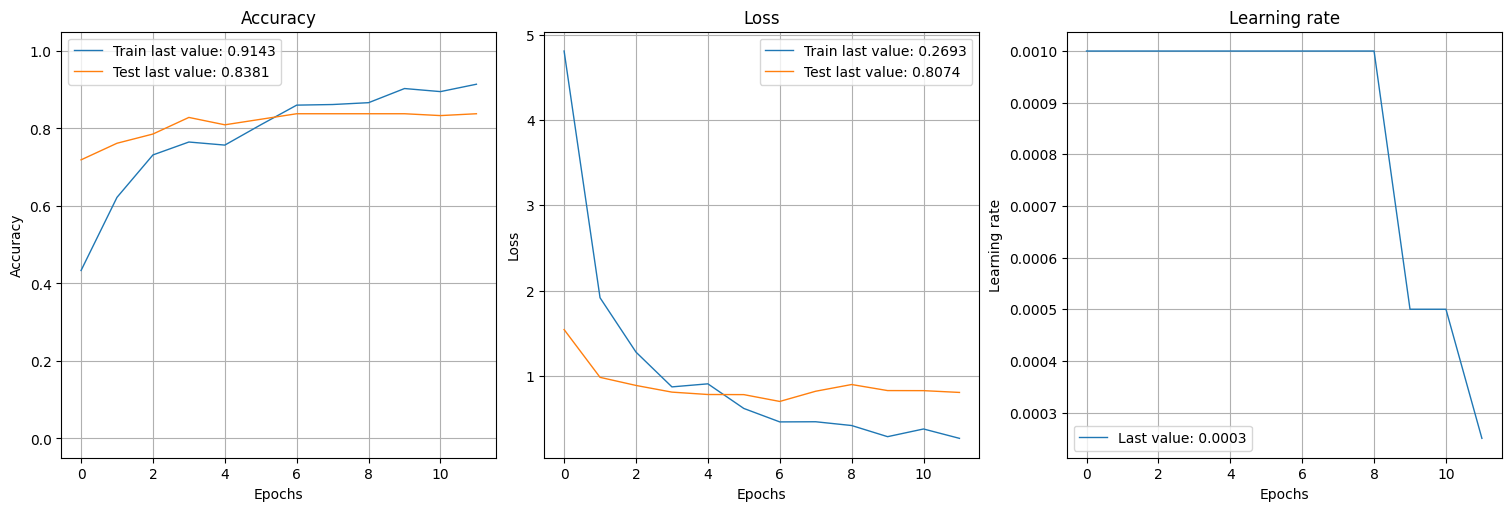

In [74]:
from plot_keras_history import show_history, plot_history
import matplotlib.pyplot as plt

show_history(history4)
plot_history(history4, path="standard.png")
plt.close()